=== METRIK ===
Total Sales: 2,261,536.78
Rata-rata Sales: 230.77
Median Sales: 54.49
Sales per Region:
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

✅ Grafik berhasil disimpan sebagai: /home/roboto/Desktop/Laporan_Analisis_Superstore.pdf


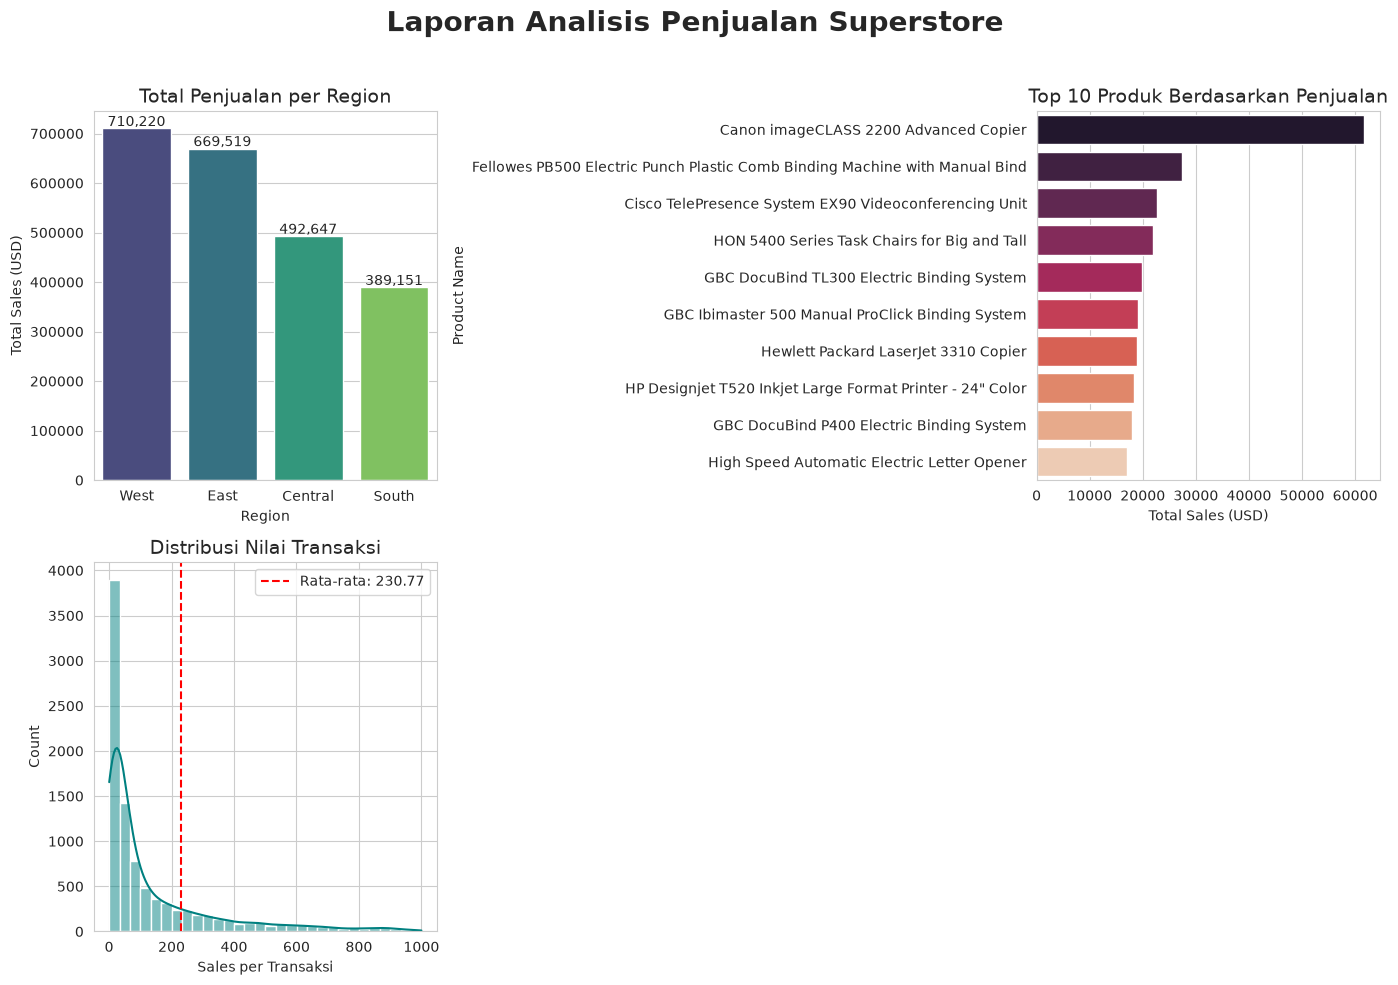

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- BACA DATA ---
csv_path = '/home/roboto/Downloads/superstore_data/train.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"File tidak ditemukan di {csv_path}")
df = pd.read_csv(csv_path)
df = df.drop_duplicates().fillna(0)

# --- METRIK ---
total_sales = df['Sales'].sum()
avg_sales = df['Sales'].mean()
med_sales = df['Sales'].median()
sales_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("=== METRIK ===")
print(f"Total Sales: {total_sales:,.2f}")
print(f"Rata-rata Sales: {avg_sales:.2f}")
print(f"Median Sales: {med_sales:.2f}")
print("Sales per Region:")
print(sales_region)

# --- SETUP GRAFIK ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Laporan Analisis Penjualan Superstore', fontsize=20, fontweight='bold')

# Grafik 1: Total Sales per Region (perbaiki warning)
sns.barplot(x=sales_region.index, y=sales_region.values, hue=sales_region.index, palette='viridis', legend=False, ax=axes[0,0])
axes[0,0].set_title('Total Penjualan per Region', fontsize=14)
axes[0,0].set_ylabel('Total Sales (USD)')
for i, v in enumerate(sales_region.values):
    axes[0,0].text(i, v + 5000, f'{v:,.0f}', ha='center', fontsize=10)

# Grafik 2: Top 10 Produk (perbaiki warning)
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=top_products.index, x=top_products.values, hue=top_products.index, palette='rocket', legend=False, ax=axes[0,1])
axes[0,1].set_title('Top 10 Produk Berdasarkan Penjualan', fontsize=14)
axes[0,1].set_xlabel('Total Sales (USD)')

# Grafik 3: Histogram
df_filtered = df[df['Sales'] <= 1000]
sns.histplot(df_filtered['Sales'], bins=30, kde=True, ax=axes[1,0], color='teal')
axes[1,0].set_title('Distribusi Nilai Transaksi', fontsize=14)
axes[1,0].set_xlabel('Sales per Transaksi')
axes[1,0].axvline(avg_sales, color='red', linestyle='--', label=f'Rata-rata: {avg_sales:.2f}')
axes[1,0].legend()

fig.delaxes(axes[1,1])
plt.tight_layout(rect=[0, 0, 1, 0.96])

# --- SIMPAN PDF KE FOLDER YANG PASTI ADA (Desktop) ---
pdf_path = os.path.expanduser('~/Desktop/Laporan_Analisis_Superstore.pdf')
plt.savefig(pdf_path, format='pdf', dpi=300)
print(f"\n✅ Grafik berhasil disimpan sebagai: {pdf_path}")

plt.show()